In [1]:
from langgraph.graph import StateGraph ,START ,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

c:\Users\Parth\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(model="gemini-flash-latest" , temperature=0)

In [4]:
class BlogState(TypedDict):

    title: str
    outline :str 
    content : str 

In [5]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'generate an detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state


In [6]:
def create_blog(state : BlogState) -> BlogState:

    # fetch title and outline 
    title = state['title']
    outline = state['outline']

    # prompt 
    prompt = f'write a detailed blog on the title - {title} using the following \n {outline}'
    content = model.invoke(prompt).content

    # update state
    state['content'] = content

    return state 


In [7]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)

# edges
graph.add_edge(START , 'create_outline')
graph.add_edge('create_outline' , 'create_blog')
graph.add_edge('create_blog' , END)

# compile 
workflow = graph.compile()


In [9]:
initial_state = {'title' : 'Rise of AI in India'}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': [{'type': 'text', 'text': 'Here is a comprehensive and detailed blog outline on the **"Rise of AI in India."** This outline is structured to be engaging, SEO-friendly, and easy to write from, covering economic, social, and technological angles.\n\n---\n\n# Blog Outline: The Rise of AI in India: From Tech Back-Office to Global Powerhouse\n\n## **Catchy Title Ideas**\n*   *The Indian AI Renaissance: How India is Shaping the Future of Artificial Intelligence*\n*   *From Code to Cognition: Inside India’s Massive AI Revolution*\n*   *Sovereign AI and Startups: Why India is the Next Big AI Frontier*\n*   *AI for All: How India is Democratizing Artificial Intelligence*\n\n---\n\n## **1. Introduction**\n*   **The Hook:** Start with a compelling statistic or anecdote (e.g., India’s rapid transition from the "IT helpdesk of the world" to a leader in cutting-edge AI development).\n*   **The Context:** Mention the foundation that made this possible—the "

In [10]:
print(final_state['outline'])

[{'type': 'text', 'text': 'Here is a comprehensive and detailed blog outline on the **"Rise of AI in India."** This outline is structured to be engaging, SEO-friendly, and easy to write from, covering economic, social, and technological angles.\n\n---\n\n# Blog Outline: The Rise of AI in India: From Tech Back-Office to Global Powerhouse\n\n## **Catchy Title Ideas**\n*   *The Indian AI Renaissance: How India is Shaping the Future of Artificial Intelligence*\n*   *From Code to Cognition: Inside India’s Massive AI Revolution*\n*   *Sovereign AI and Startups: Why India is the Next Big AI Frontier*\n*   *AI for All: How India is Democratizing Artificial Intelligence*\n\n---\n\n## **1. Introduction**\n*   **The Hook:** Start with a compelling statistic or anecdote (e.g., India’s rapid transition from the "IT helpdesk of the world" to a leader in cutting-edge AI development).\n*   **The Context:** Mention the foundation that made this possible—the "India Stack" (UPI, Aadhaar, cheap mobile dat

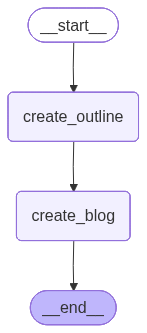

In [12]:
# How to visualize the graph

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())